## Desarrollo tarea HW Sesión 2

Felipe López Vergara

Descarga de librerías necesarias

In [1]:
# Librerías necesarias — no modifique esta celda
from matplotlib import pyplot as plt
from scipy.stats import f_oneway, mannwhitneyu, kruskal, levene, bartlett
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import yfinance as yf
import pandas as pd
import numpy as np

sns.set_style("dark")
np.random.seed(20260607)

### Parte I: Transformación de Datos Financieros (25 puntos)

Trabajará con el siguiente portafolio de activos del sector tecnológico y financiero para el período 2021-01-01 al 2024-12-31:

Ticker	Empresa
AAPL	Apple Inc.
AMZN	Amazon.com Inc.
JPM	    JPMorgan Chase & Co.
GS	    Goldman Sachs Group Inc.
TSLA	Tesla Inc.

Pregunta 1.1 — Retornos Simples y Logarítmicos (8 puntos)

a) Descargue los precios de cierre del portafolio definido anteriormente.

In [2]:
# Extracción de datos utilizando yfinance
def descargar_datos_yf(tickers, start, end):
    data = yf.download(tickers, start=periodo[0], end=periodo[1], progress=False)
    return data

tickers = ['AAPL', 'AMZN','JPM', 'GS', 'TSLA']
periodo = ('2021-01-01', '2024-12-31')

df = descargar_datos_yf(tickers, periodo[0], periodo[1])['Close']
df.head()

Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-04,125.740837,159.331497,233.060928,109.491562,243.256668
2021-01-05,127.295502,160.925507,238.276199,110.087334,245.036667
2021-01-06,123.010521,156.919006,251.134155,115.256577,251.993332
2021-01-07,127.208015,158.108002,256.498962,119.041519,272.013336
2021-01-08,128.305969,159.134995,255.118164,119.172951,293.339996


b) Calcule los retornos diarios simples y logarítmicos para cada activo.

In [3]:
# Cálculos de retornos del DataFrame
retornos_simple = df.pct_change().dropna()
retornos_log = np.log(df / df.shift(1))

retornos_simple.head()



Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-05,0.012364,0.010004,0.022377,0.005441,0.007317
2021-01-06,-0.033662,-0.024897,0.053962,0.046956,0.028390
2021-01-07,0.034123,0.007577,0.021362,0.032839,0.079447
2021-01-08,0.008631,0.006496,-0.005383,0.001104,0.078403
2021-01-11,-0.023249,-0.021519,0.012927,0.014924,-0.078214


c) Para el activo TSLA, grafique en un mismo panel de dos subplots: la serie de precios y la serie de retornos logarítmicos.

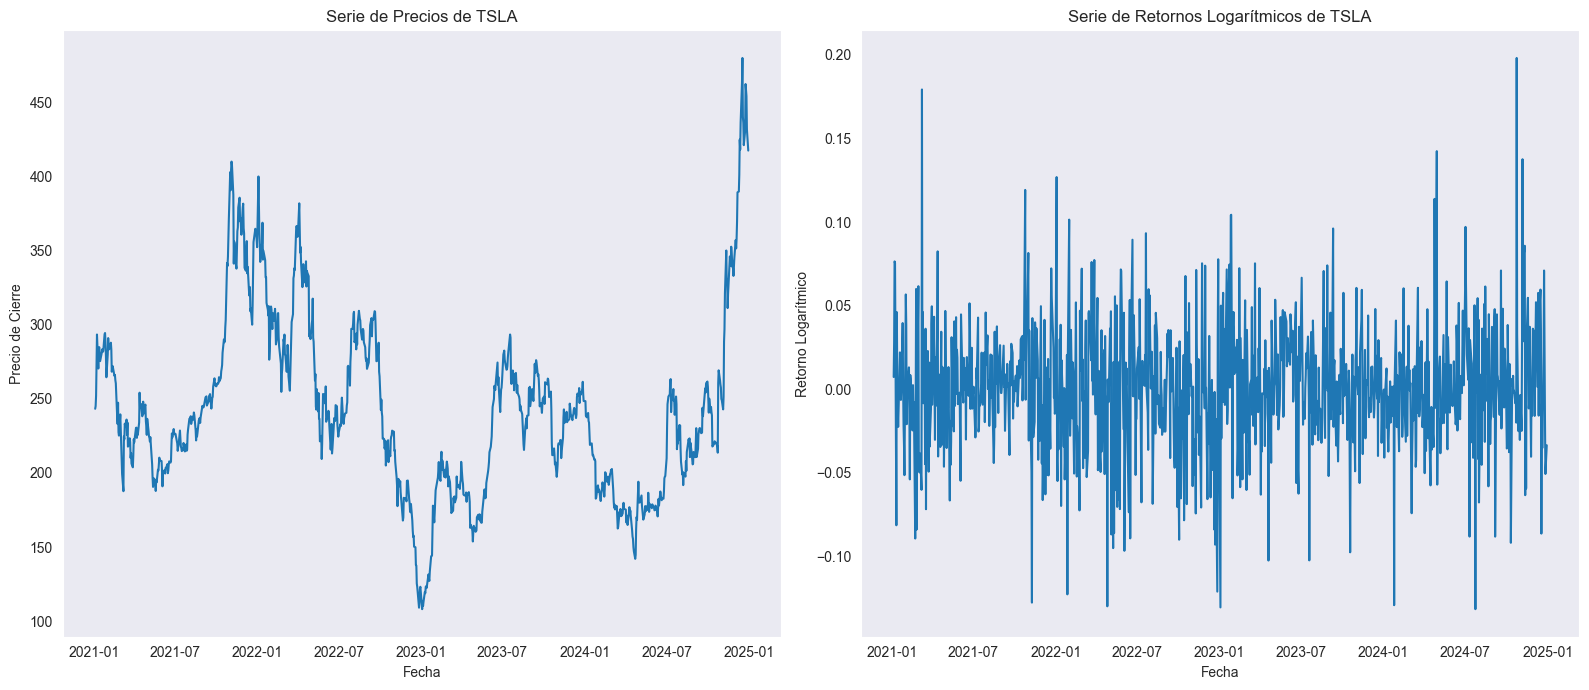

In [4]:
# Serie de Precios y Retornos logarítmicos de Tesla

fig, axes = plt.subplots(1, 2, figsize = (16, 7))

sns.lineplot(data = df['TSLA'], ax = axes[0])
axes[0].set_title('Serie de Precios de TSLA')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Precio de Cierre')  

sns.lineplot(data = retornos_log['TSLA'], ax = axes[1])
axes[1].set_title('Serie de Retornos Logarítmicos de TSLA')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Retorno Logarítmico')

plt.tight_layout() 
plt.show()


d) ¿Qué diferencias observa entre los retornos simples y logarítmicos? ¿En qué escenarios es más conveniente usar retornos logarítmicos? Justifique su respuesta.

### Pregunta 1.2 — Retornos Multi-Período (9 puntos)

Para el activo **JPM**:

a) Calcule los retornos **diarios, semanales y mensuales** (simples y logarítmicos).

In [5]:
#Retonro diario de JPM
ret_diario_simple_jpm = df['JPM'].pct_change().dropna()
ret_diario_log_jpm = np.log(df['JPM'] / df['JPM'].shift(1))

#Retonro semanal de JPM
precios_semanal_jpm = df['JPM'].resample('W').last()
ret_semanal_simple_jpm = precios_semanal_jpm.pct_change().dropna()
ret_semanal_log_jpm = np.log(precios_semanal_jpm / precios_semanal_jpm.shift(1))

#Retonro mensual de JPM
precios_mensual_jpm = df['JPM'].resample('ME').last()
ret_mensual_simple_jpm = precios_mensual_jpm.pct_change().dropna()
ret_mensual_log_jpm = np.log(precios_mensual_jpm / precios_mensual_jpm.shift(1))


b) Calcule el retorno acumulado a rolling 20 días usando retornos logarítmicos (recuerde la propiedad de aditividad: $r_t(k) =\\suma_{i=0}^{k-1} r_{ti}$).


In [6]:
#Retorno a 20 días de JPM

rolling_20d_log_jpm = np.log(df['JPM'] / df['JPM'].shift(20))

c) Visualice en un solo gráfico el retorno logarítmico diario y el retorno rolling de 20 días para JPM.

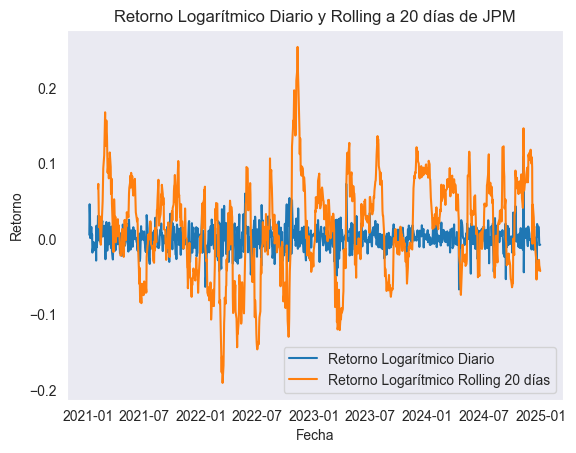

In [7]:
#Gráficos de Retornos logarítmico diario y retorno rolling a 20 días de JPM

sns.lineplot(data = ret_diario_log_jpm, label = 'Retorno Logarítmico Diario')
sns.lineplot(data = rolling_20d_log_jpm, label = 'Retorno Logarítmico Rolling 20 días')
plt.title('Retorno Logarítmico Diario y Rolling a 20 días de JPM')
plt.xlabel('Fecha')
plt.ylabel('Retorno')
plt.legend()
plt.show()


d) Calcule la media, desviación estándar, asimetría (skewness) y curtosis para los retornos diarios de cada frecuencia (diario, semanal, mensual). Presente los resultados en un DataFrame resumen.

In [8]:
# Función para calcular estadísticas

def calcular_estadisticas(retornos):
    return pd.Series({
        'Media': retornos.mean(),
        'Mediana': retornos.median(),
        'Desviación Estándar': retornos.std(),
        'Curtosis': retornos.kurtosis(),
        'Asimetría': retornos.skew()
    })

# DataFrame resumen
estadisticas_jpm = pd.DataFrame({
    'Retorno Diario Simple': calcular_estadisticas(ret_diario_simple_jpm),
    'Retorno Diario Logarítmico': calcular_estadisticas(ret_diario_log_jpm),
    'Retorno Semanal Simple': calcular_estadisticas(ret_semanal_simple_jpm),
    'Retorno Semanal Logarítmico': calcular_estadisticas(ret_semanal_log_jpm),
    'Retorno Mensual Simple': calcular_estadisticas(ret_mensual_simple_jpm),
    'Retorno Mensual Logarítmico': calcular_estadisticas(ret_mensual_log_jpm)
})

print(estadisticas_jpm)

                     Retorno Diario Simple  Retorno Diario Logarítmico  \
Media                             0.000865                    0.000749   
Mediana                           0.001104                    0.001103   
Desviación Estándar               0.015214                    0.015174   
Curtosis                          4.957111                    4.402312   
Asimetría                         0.335348                    0.186648   

                     Retorno Semanal Simple  Retorno Semanal Logarítmico  \
Media                              0.003779                     0.003205   
Mediana                            0.006998                     0.006974   
Desviación Estándar                0.033809                     0.033794   
Curtosis                           0.704803                     0.662756   
Asimetría                         -0.095355                    -0.227735   

                     Retorno Mensual Simple  Retorno Mensual Logarítmico  
Media                  

### Pregunta 1.3 — Estandarización y Normalización (8 puntos)

a) Tome los retornos diarios simples del portafolio completo (5 activos). Aplique estandarización (Standard Scaler) y normalización (Min-Max Scaler) a cada serie de retornos.

In [9]:
# Estandarización (Standar Scaling)
scaler = StandardScaler()
X_scaled_standard = scaler.fit_transform(retornos_simple)

# Normalización (Min-Max Scaling)
scaler = MinMaxScaler()
X_scaled_minmax = scaler.fit_transform(retornos_simple)

b) Para los activos AAPL y TSLA, grafique en un panel de 3 columnas (original, estandarizado, normalizado) los histogramas de retornos.

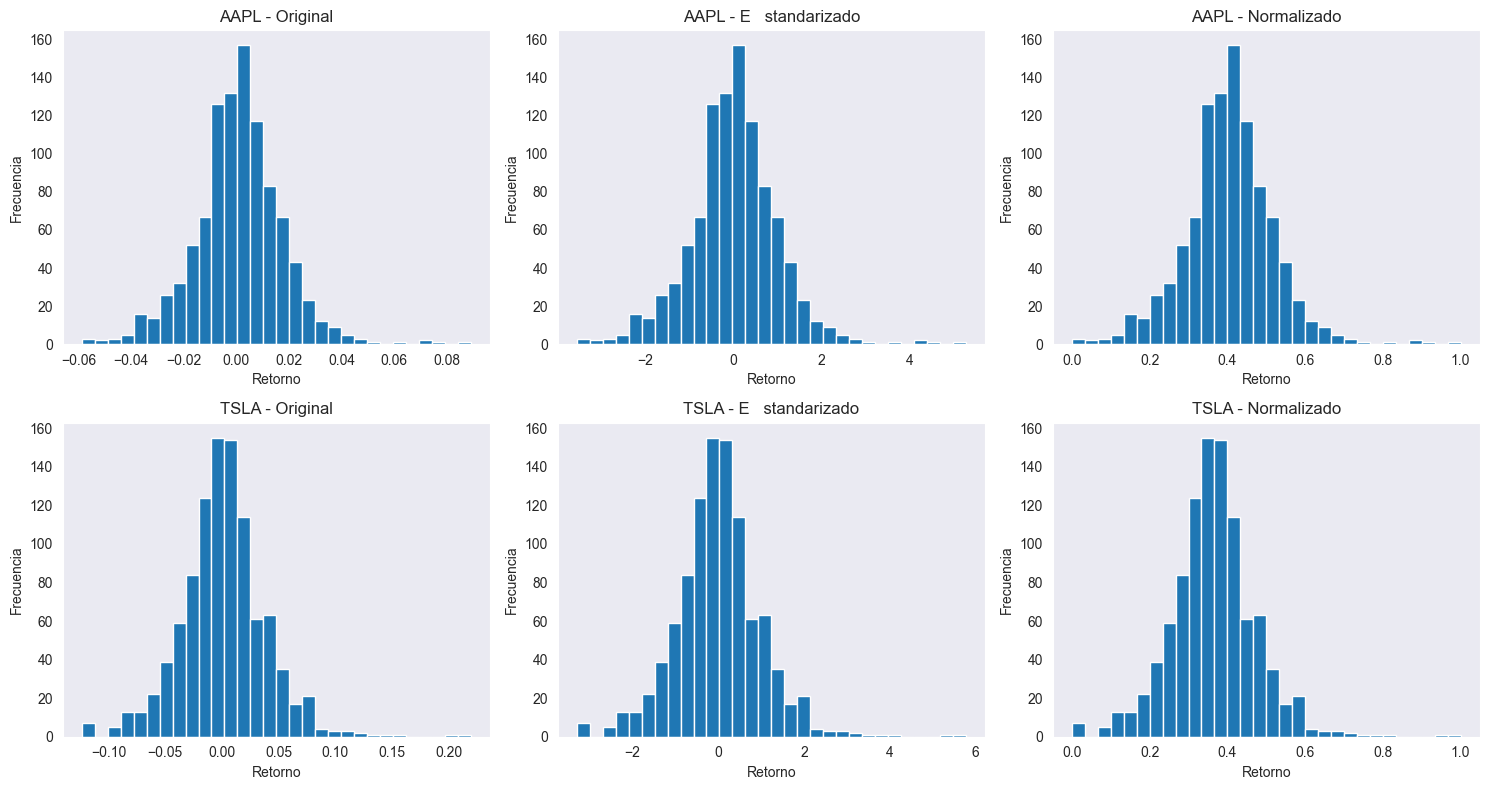

In [10]:
# Gráficos Retornos diarios, normalizados y estandarizados de AAPL y TSLA

# Seleccionar activos
acciones = retornos_simple[['AAPL', 'TSLA']].dropna()

# Estandarización 
scaler_std = StandardScaler()
df_std = pd.DataFrame(
    scaler_std.fit_transform(acciones),
    columns=acciones.columns,
    index=acciones.index
)

# Normalización 
scaler_norm = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler_norm.fit_transform(acciones),
    columns=acciones.columns,
    index=acciones.index      
)

# Crear gráficos de histogramas para cada acción y cada tipo de retorno
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

activos = ['AAPL', 'TSLA']
datasets = [acciones, df_std, df_norm]
titulos = ['Original', 'E   standarizado', 'Normalizado']

for i, activo in enumerate(activos):
    for j, (data, titulo) in enumerate(zip(datasets, titulos)):
        axes[i, j].hist(data[activo], bins=30)
        axes[i, j].set_title(f'{activo} - {titulo}')
        axes[i, j].set_xlabel('Retorno')
        axes[i, j].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

c) ¿Cuál de las dos transformaciones es más adecuada para comparar la volatilidad relativa entre los activos del portafolio? Justifique.

## Parte II: Análisis de Relaciones y Estructura de Riesgo (25 puntos)

### Pregunta 2.1 — Matrices de Correlación (10 puntos)

a) Calcule las matrices de correlación de Pearson, Spearman y Kendall para los 5 activos.

In [11]:
# Correlación de Pearson
retornos_simple.corr(method='pearson')

Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,1.000000,0.562226,0.332047,0.294701,0.492028
AMZN,0.562226,1.000000,0.359423,0.295769,0.427575
GS,0.332047,0.359423,1.000000,0.763536,0.287262
JPM,0.294701,0.295769,0.763536,1.000000,0.261380
TSLA,0.492028,0.427575,0.287262,0.261380,1.000000


In [12]:
# Correlación de Spearman
retornos_simple.corr(method='spearman')

Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,1.000000,0.595983,0.332782,0.292711,0.503423
AMZN,0.595983,1.000000,0.331139,0.272547,0.458631
GS,0.332782,0.331139,1.000000,0.745477,0.302991
JPM,0.292711,0.272547,0.745477,1.000000,0.275198
TSLA,0.503423,0.458631,0.302991,0.275198,1.000000


In [13]:
# Correlación de Kendall
retornos_simple.corr(method='kendall')

Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,1.000000,0.431524,0.230996,0.204111,0.352090
AMZN,0.431524,1.000000,0.228477,0.189078,0.320922
GS,0.230996,0.228477,1.000000,0.562387,0.207611
JPM,0.204111,0.189078,0.562387,1.000000,0.187276
TSLA,0.352090,0.320922,0.207611,0.187276,1.000000


b) Visualice las tres matrices en un panel de 3 heatmaps con anotaciones numéricas.

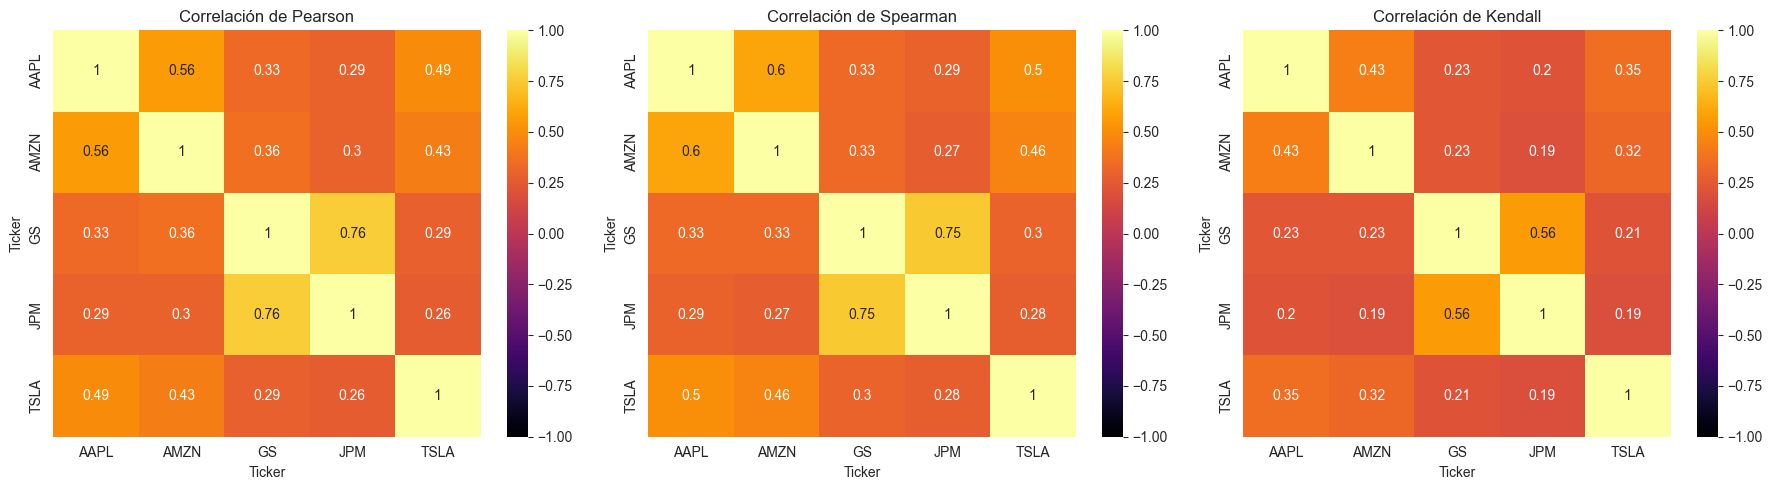

In [14]:
#Creación de mapas heatmap para cada tipo de correlación
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(retornos_simple.corr(method='pearson'), annot=True, cmap='inferno', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlación de Pearson')

sns.heatmap(retornos_simple.corr(method='spearman'), annot=True, cmap='inferno', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Correlación de Spearman')

sns.heatmap(retornos_simple.corr(method='kendall'), annot=True, cmap='inferno', ax=axes[2], vmin=-1, vmax=1)
axes[2].set_title('Correlación de Kendall')

plt.tight_layout()
plt.show()

c) Identifique el par de activos con mayor y menor correlación de Pearson.

Los

Compare los resultados entre Pearson y Spearman. ¿Existen diferencias relevantes? ¿A qué se pueden deber estas diferencias en el contexto de retornos financieros?

Al 

### Pregunta 2.2 — Matriz de Covarianza (8 puntos)

a) Calcule la matriz de varianzas y covarianzas para los retornos mensuales del portafolio.

In [15]:
#Matriz de covarianza de los retornos mensuales simples

retorno_mensual_simple = df.resample('ME').last().pct_change().dropna()
retorno_mensual_covarianza = retorno_mensual_simple.cov()

retorno_mensual_covarianza

Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,0.005452,0.004582,0.002046,0.001129,0.007980
AMZN,0.004582,0.008780,0.002156,0.001260,0.010944
GS,0.002046,0.002156,0.006626,0.005119,0.003233
JPM,0.001129,0.001260,0.005119,0.005446,0.001130
TSLA,0.007980,0.010944,0.003233,0.001130,0.032387


b) Verifique que es semidefinida positiva calculando sus valores propios (eigenvalues) e imprimiéndolos. ¿Qué condición deben cumplir?

In [16]:
# Matriz de correlación o covarianza
eigenvalues = np.linalg.eigvals(retorno_mensual_covarianza)

print("Valores propios:")
print(eigenvalues)

Valores propios:
[0.03984997 0.01097119 0.00484331 0.00221905 0.00080758]


Deben cumplir la condición de que todos sus valores propios son mayores o iguales a cero.

c) A partir de $\\Sigma$ , calcule la volatilidad anualizada de cada activo. Recuerde que $\\sigma_{\\texto{anual}} =\\sigma_{\\texto{mensual}}\\veces\\sqrt{12}$.

In [17]:
# Volatilidades mensuales
vol_mensual = np.sqrt(np.diag(retorno_mensual_covarianza))

# Volatilidades anualizadas
vol_anual = vol_mensual * np.sqrt(12)

# Mostrar resultados
volatilidades = pd.DataFrame({
    'Volatilidad Mensual': vol_mensual,
    'Volatilidad Anualizada': vol_anual
}, index=retorno_mensual_covarianza.index)

print(volatilidades)

        Volatilidad Mensual  Volatilidad Anualizada
Ticker                                             
AAPL               0.073838                0.255781
AMZN               0.093700                0.324587
GS                 0.081402                0.281983
JPM                0.073799                0.255649
TSLA               0.179963                0.623412


d) Según la covarianza, ¿qué par de activos ofrece mejor diversificación? Justifique.

Según 

### Pregunta 2.3 — Correlaciones Rodantes (Rolling Correlation) (7 puntos)

a) Calcule la correlación de Pearson rolling de 60 días entre los retornos de AAPL y JPM.

In [18]:
#Retorno a 60 días de AAPL y JPM

corr_rolling = retornos_simple['AAPL'].rolling(window=60).corr(retornos_simple['JPM'])


b) Grafique esta correlación rodante en el tiempo, marcando con una línea horizontal la correlación promedio del período.

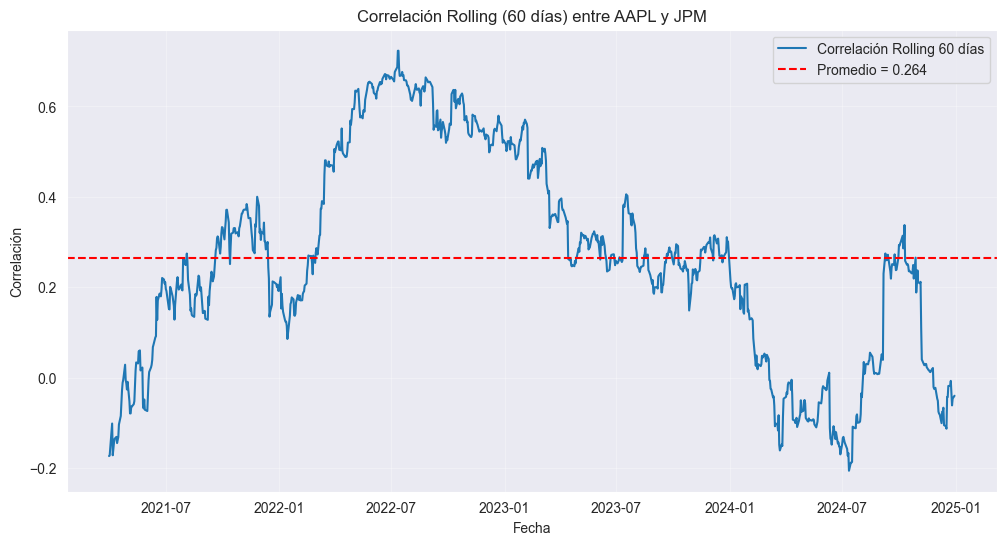

In [19]:
# Correlación promedio del período
corr_promedio = corr_rolling.mean()

#Gráfico de dispersión entre retorno a 60 días de AAPL y JPM´

plt.figure(figsize=(12,6))
plt.plot(corr_rolling.index, corr_rolling,
         label='Correlación Rolling 60 días', linewidth=1.5)

plt.axhline(y=corr_promedio,
            color='red',
            linestyle='--',
            label=f'Promedio = {corr_promedio:.3f}')

plt.title('Correlación Rolling (60 días) entre AAPL y JPM')
plt.xlabel('Fecha')
plt.ylabel('Correlación')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

c) Identifique visualmente en el gráfico al menos dos períodos en los que la correlación haya sido inusualmente alta o baja. Proponga una explicación financiera para cada uno (puede apoyarse en eventos de mercado conocidos del período 2021–2024).

Se 

## Parte III: Comparación Estadística de Activos (20 puntos)

### Pregunta 3.1 — Visualización de Distribuciones (5 puntos)

a) Genere un violin plot con los retornos diarios de los 5 activos del portafolio.
b) Agregue al gráfico una línea horizontal en 
 para identificar el nivel de quiebre entre retornos positivos y negativos.

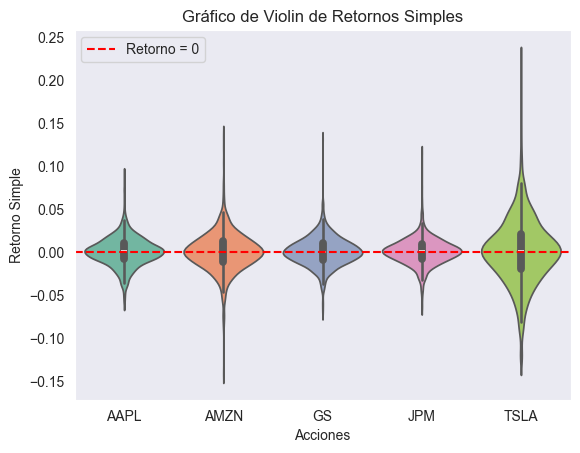

In [20]:
#Gráfico de violin

sns.violinplot(data=retornos_simple, orient = 'v', palette='Set2')

#Línea Horizontal en y=0
plt.axhline(y=0,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label='Retorno = 0')

plt.title('Gráfico de Violin de Retornos Simples')
plt.xlabel('Acciones')
plt.ylabel('Retorno Simple')
plt.legend()
plt.show()


c) ¿Qué activo presenta la mayor dispersión de retornos? ¿Cuál presenta la distribución más asimétrica? Interprete los resultados desde una perspectiva de riesgo.

El 

### Pregunta 3.2 — Tests de Igualdad de Medias (8 puntos)

Queremos evaluar si los retornos promedio de los 5 activos son estadísticamente distintos entre sí.

a) Aplique el **Test ANOVA** ($H_0$: las medias son iguales) y el **Test de Kruskal-Wallis** ($H_0$: las medianas son iguales). Utilice $\\alfa = 0,05$.

In [21]:
#Test de ANOVA 

f_oneway_resultado = f_oneway(retornos_simple['AAPL'], retornos_simple['AMZN'], retornos_simple['JPM'], retornos_simple['GS'], retornos_simple['TSLA'])  
print(f"ANOVA F-statistic: {f_oneway_resultado.statistic}, p-value: {f_oneway_resultado.pvalue}")

#Test de Kruskal-Wallis
kruskal_resultado = kruskal(retornos_simple['AAPL'], retornos_simple['AMZN'], retornos_simple['JPM'], retornos_simple['GS'], retornos_simple['TSLA'])
print(f"Kruskal-Wallis H-statistic: {kruskal_resultado.statistic}, p-value: {kruskal_resultado.pvalue}")

ANOVA F-statistic: 0.11317912226913177, p-value: 0.9779314585166656
Kruskal-Wallis H-statistic: 0.20537792954706816, p-value: 0.9950749137055173


b) Para el par AAPL vs TSLA, aplique el Test de Mann-Whitney U y formule explícitamente las hipótesis $H_0$ y $H_1$

In [22]:
#Test de Mann-Whitney U 
mannwhitney_resultado = mannwhitneyu(retornos_simple['AAPL'], retornos_simple['TSLA'])
print(f"Mann-Whitney U statistic: {mannwhitney_resultado.statistic}, p-value: {mannwhitney_resultado.pvalue}")

#Hipótesis nula (H0): 
# Los retornos diarios de AAPL y TSLA provienen de poblaciones con la misma distribución (o equivalentemente, tienen la misma mediana si las distribuciones tienen forma similar).
#H0​:x~AAPL​=x~TSLA​

#Hipótesis alternativa (H1): 
#Los retornos diarios de AAPL y TSLA provienen de poblaciones con distribuciones diferentes (o medianas diferentes).
#H1​:x~AAPL​≠x~TSLA​
#Para un nivel de significancia α=0.05:

#Si p-value<0.05: rechazamos H_0.
#Si p-value≥0.05: no rechazamos H0


Mann-Whitney U statistic: 503018.5, p-value: 0.9991695953795808


c) Presente los resultados de los tres tests en un DataFrame con columnas: Test, Estadístico, p-valor, Decisión.

In [23]:
# Extraer cada serie de retornos
series = [retornos_simple[col].dropna() for col in retornos_simple.columns]

# Nivel de significancia
alpha = 0.05

# ANOVA
stat_anova, p_anova = f_oneway(*series)

# Kruskal-Wallis
stat_kw, p_kw = kruskal(*series)

# 1. Mann-Whitney U
stat_mw, p_mw = mannwhitneyu(retornos_simple['AAPL'], retornos_simple['TSLA'], alternative='two-sided')

# Resultados
resultados = pd.DataFrame({
    'Test': ['ANOVA', 'Kruskal-Wallis', 'Mann-Whitney U'],
    'Estadístico': [stat_anova, stat_kw, stat_mw],
    'p-valor': [p_anova, p_kw, p_mw]
})

resultados['Decisión'] = resultados['p-valor'].apply(
    lambda p: 'Rechazar H₀' if p < alpha else 'No rechazar H₀'
)

resultados = resultados.round({
    'Estadístico': 4,
    'p-valor': 6
})

print(resultados)

             Test  Estadístico   p-valor        Decisión
0           ANOVA       0.1132  0.977931  No rechazar H₀
1  Kruskal-Wallis       0.2054  0.995075  No rechazar H₀
2  Mann-Whitney U  503018.5000  0.999170  No rechazar H₀


d) ¿Coinciden los tests paramétricos y no paramétricos en sus conclusiones? ¿Cuándo es más apropiado usar los no paramétricos en el análisis de retornos financieros?

En 

### Pregunta 3.3 — Tests de Igualdad de Varianzas (7 puntos)

a) Aplique el Test de Levene y el Test de Bartlett para los 5 activos. Use a=0.05
b) Presente los resultados en un DataFrame resumen similar al de la pregunta anterior.

In [24]:
# Extraer cada serie de retornos
series2 = [retornos_simple[col].dropna() for col in retornos_simple.columns]

# Nivel de significancia
alpha = 0.05

#Test de Levene
stat_levene, p_levene = levene(*series2)

#Test de Bartlett
stat_bartlett, p_bartlett = bartlett(*series2)

# Resultados
resultados = pd.DataFrame({
    'Test': [ 'Levene', 'Bartlett'],
    'Estadístico': [stat_levene, stat_bartlett],
    'p-valor': [p_levene, p_bartlett]
})

resultados['Decisión'] = resultados['p-valor'].apply(
    lambda p: 'Rechazar H₀' if p < alpha else 'No rechazar H₀'
)

resultados = resultados.round({
    'Estadístico': 4,
    'p-valor': 6
})

print(resultados)


       Test  Estadístico  p-valor     Decisión
0    Levene     185.4356      0.0  Rechazar H₀
1  Bartlett    1318.3261      0.0  Rechazar H₀


c) Basándose en los resultados, ¿puede concluir que algún activo tiene una volatilidad significativamente distinta al resto? ¿Qué implicancias tiene esto para la construcción de un portafolio diversificado?


Los 

d) ¿Por qué puede existir diferencia entre los resultados de Levene y Bartlett? ¿Cuál es más apropiado para datos financieros?

pueden


## Parte IV: Distribuciones Muestrales y Teorema del Límite Central (20 puntos)

### Pregunta 4.1 — Distribución Muestral del Retorno Promedio (10 puntos)

Usando los retornos diarios de GS (Goldman Sachs):

a) Grafique el histograma de los retornos diarios e indique visualmente si la distribución parece normal. Calcule la asimetría y curtosis de la distribución real.

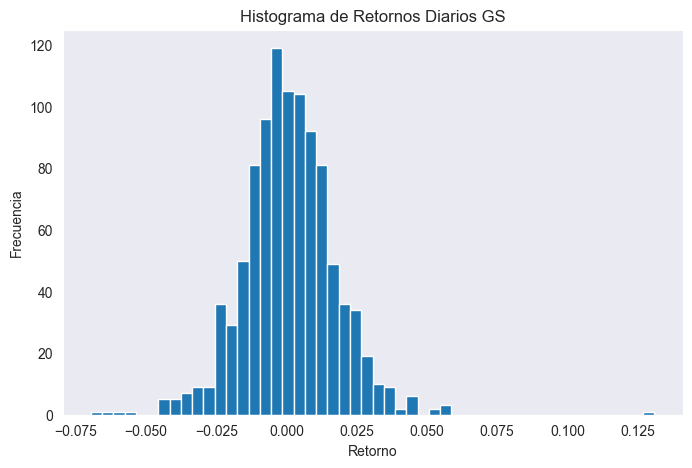

Asimetría: 0.4214
Curtosis: 4.5688


In [31]:
#Retonro diario de GS
ret_diario_simple_gs = df['GS'].pct_change().dropna()

# Histograma
plt.figure(figsize=(8,5))
plt.hist(ret_diario_simple_gs, bins=50)
plt.title('Histograma de Retornos Diarios GS')
plt.xlabel('Retorno')
plt.ylabel('Frecuencia')
plt.show()

# Estadísticos
Asimetria = ret_diario_simple_gs.skew()
Kurt = ret_diario_simple_gs.kurt()

print(f"Asimetría: {Asimetria:.4f}")
print(f"Curtosis: {Kurt:.4f}")

Visualmente los retornos diarios de GS parece si se a una distribución normal.

b) Mediante simulación Monte Carlo (5.000 repeticiones), construya la distribución muestral del retorno promedio $\\bar{R}$ para los tamaños muestrales $n\\en\\{5, 20, 60, 120, 252\\}$.

In [41]:
# Media muestral de los retornos de GS
ret_diario_simple_gs_100 = df['GS'].pct_change().dropna()*100


n_values = [5, 20, 60, 120, 252]
n_sim = 5000
retorno_muestral = {}

np.random.seed(42)

for n in n_values:

    medias = np.empty(n_sim)

    for i in range(n_sim):
        muestra = np.random.choice(ret_diario_simple_gs_100,
                                   size=n,
                                   replace=True)
        medias[i] = np.mean(muestra)

    retorno_muestral[n] = medias


c) Grafique un panel de 5 histogramas (uno por cada n) con la media y desviación estándar de cada distribución muestral.

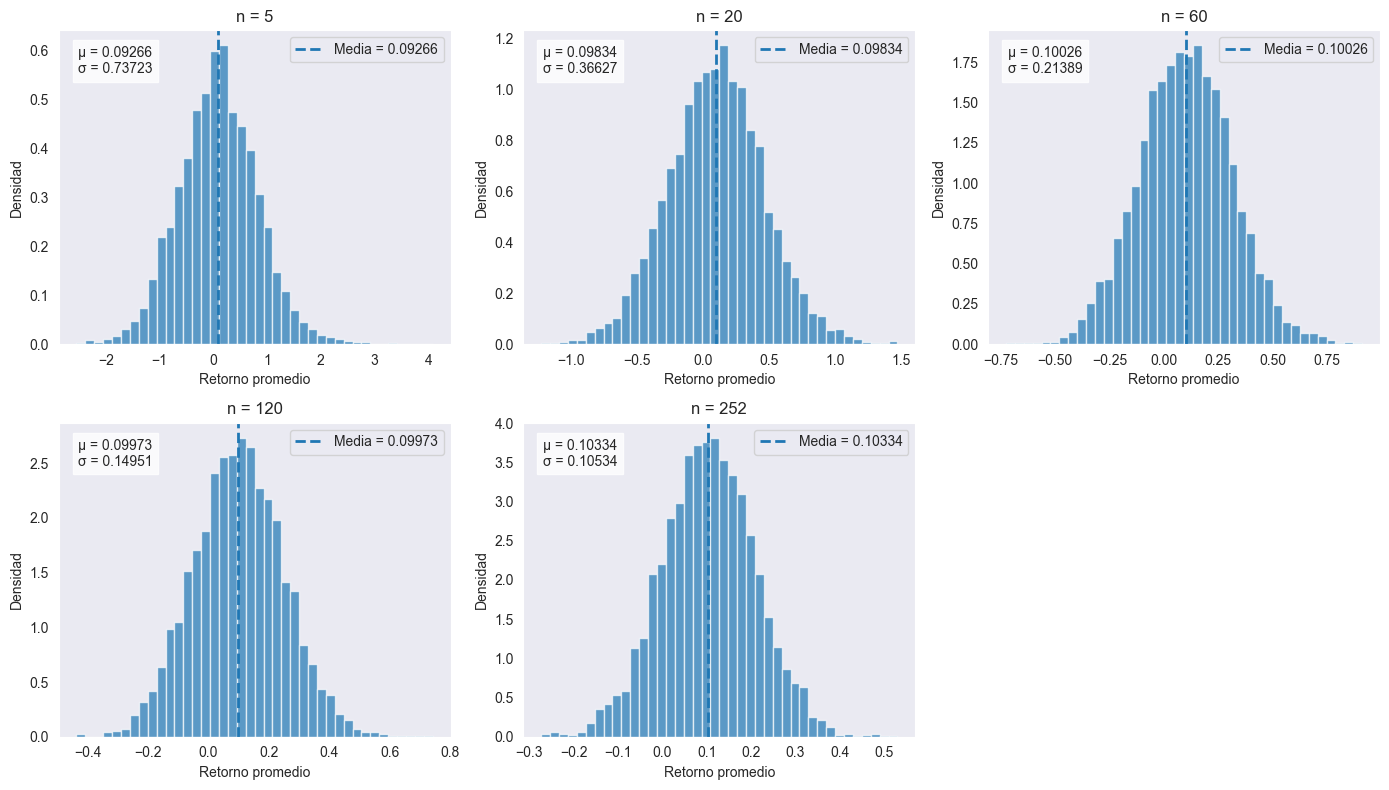

In [42]:
# Gráfico de histogramas

fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

for i, n in enumerate(n_values):

    medias = retorno_muestral[n]

    media = np.mean(medias)
    std = np.std(medias)

    axes[i].hist(medias,
                 bins=40,
                 density=True,
                 alpha=0.7)

    axes[i].axvline(media,
                    linestyle='--',
                    linewidth=2,
                    label=f'Media = {media:.5f}')

    axes[i].set_title(f'n = {n}')
    axes[i].set_xlabel('Retorno promedio')
    axes[i].set_ylabel('Densidad')

    axes[i].text(0.05,
                 0.95,
                 f'μ = {media:.5f}\nσ = {std:.5f}',
                 transform=axes[i].transAxes,
                 verticalalignment='top',
                 bbox=dict(facecolor='white', alpha=0.8))

    axes[i].legend()

# Eliminar el sexto subplot vacío
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

d) ¿Cómo cambia la forma de la distribución muestral a medida que n crece? Relacione su observación con el Teorema del Límite Central y discuta su relevancia para la estimación de retornos esperados.

A 